In [1]:
using JuMP, HiGHS, Random, PrettyTables, JSON, GeoJSON, CSV
using DataFrames
import Plots, Printf
import Distributions
import SparseArrays
using LinearAlgebra
using StatsPlots
using Distributions

In [2]:
function haversine(lat1, lon1, lat2, lon2)
    
    radius = 3958.8
    
    lat1_rad = deg2rad(lat1)
    lon1_rad = deg2rad(lon1)
    lat2_rad = deg2rad(lat2)
    lon2_rad = deg2rad(lon2)
    
    
    ds = lon2_rad - lon1_rad
    
    
    angle = acos(sin(lat1_rad) * sin(lat2_rad) + cos(lat1_rad) * cos(lat2_rad) * cos(ds))
    
    distance = radius * angle
    return distance
end

haversine (generic function with 1 method)

geography of 15 counties.


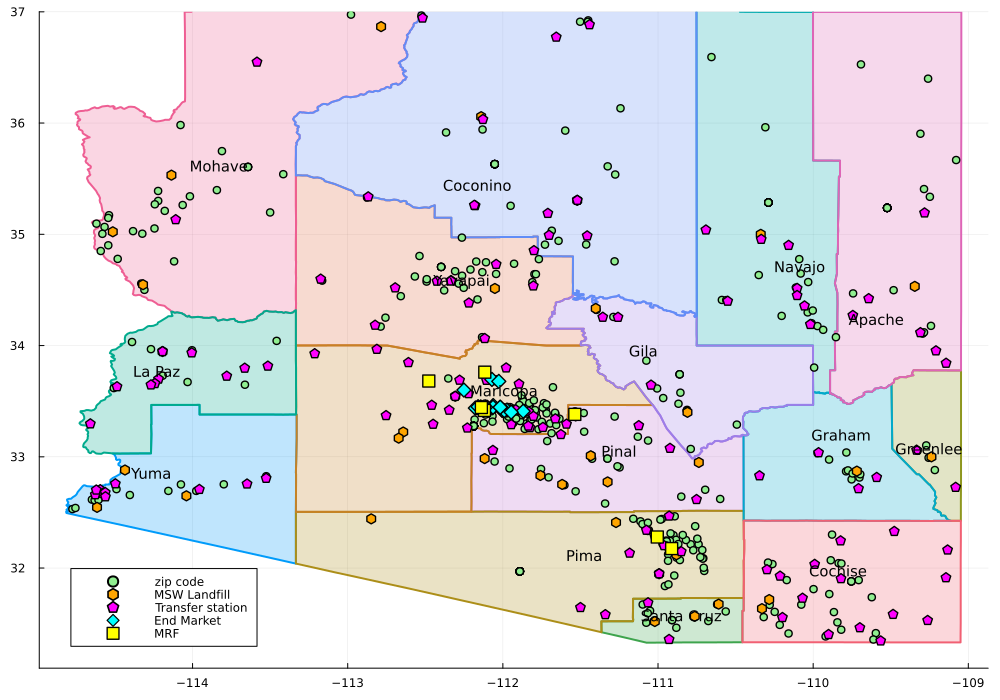

In [13]:
zip = DataFrame(CSV.File("AZ_zip.csv"))
facility = DataFrame(CSV.File("Location.csv"))
landfill = DataFrame(CSV.File("Landfills.csv"))
Transfer_station = DataFrame(CSV.File("Transfer Station.csv"))
map = JSON.parsefile("AZ.geojson")
features = map["features"]
plot_shapes = []
counties = []

for feature in features
    coordinates = feature["geometry"]["coordinates"]
    county = feature["properties"]["name"]
    for geo in coordinates

        longitudes = [coord[1] for coord in geo]
        latitudes = [coord[2] for coord in geo]
        
        push!(plot_shapes, Shape(longitudes, latitudes))
        push!(counties, county)
    end
end

println("geography of ", length(plot_shapes), " counties.")
coordinates = map["features"][2]["geometry"]["coordinates"][1]
longitudes = [coord[1] for coord in coordinates]
latitudes = [coord[2] for coord in coordinates]
data = DataFrame(plots_shapes=plot_shapes, value=rand(33.2:35, length(plot_shapes)), county=counties)
anim = Animation()

qq = plot()

for (i, shape) in enumerate(data.plots_shapes)
    longitudes = shape.x
    latitudes = shape.y
    county_name = data.county[i]
    value = data.value[i]
    
    # regions
    plot!(qq, longitudes, latitudes, fillrange=0, fillalpha=0.25, yrange = (31.1, 37), size = (1000, 700), label=false, linewidth=2)

    centroid_lon = mean(longitudes)
    centroid_lat = mean(latitudes)
    
    #  county name
    annotate!(qq, centroid_lon, centroid_lat, text(county_name, 10, :black))
end
scatter!(qq, zip[:, 3], zip[:, 2], markercolor = :lightgreen, label = "zip code", markershape = :circle, markersize = 2 .* (2.0))
scatter!(qq, landfill[:, 4], landfill[:, 3], markercolor = :orange, label = "MSW Landfill", markershape = :hexagon, markersize = 2 .* (2.5))
scatter!(qq, Transfer_station[:, 4], Transfer_station[:, 3], markercolor = :magenta, label = "Transfer station", markershape = :pentagon, markersize = 2 .* (2.5))
scatter!(qq, facility[23:41, 3], facility[23:41, 2], markercolor = :cyan, label = "End Market", markershape = :diamond, markersize = 2 .* (3.5))
scatter!(qq, facility[1:7, 3], facility[1:7, 2], markercolor = :yellow, label = "MRF", markershape = :rect, markersize = 2 .* (3.0))
#scatter!(qq, [zip[462:468, 3]], [zip[462:468, 2]], markercolor = :lightgreen, label = "Model Spokes", markershape = :circle, markersize = 2 .* (4.5))
#scatter!(qq, [zip[438, 3]], [zip[438, 2]], markercolor = :magenta, label = "Model Transfer station", markershape = :pentagon, markersize = 2 .* (4.5))
plot(qq)

In [4]:
MRF_dx = facility[1:7, 2]
S_dx = zip[462:468, 2]
TS_dx = zip[438:438, 2]
EM_dx = facility[23:26,2]
MRF_dy = facility[1:7, 3]
S_dy = zip[462:468, 3]
TS_dy = zip[438:438, 3]
EM_dy = facility[23:26,3]
dS = [haversine(S_dx[i], S_dy[i], S_dx[j], S_dy[j]) for i in 1:length(S_dx), j in 1:length(S_dx)]
dS_TS = [haversine(S_dx[i], S_dy[i], TS_dx[j], TS_dy[j]) for i in 1:length(S_dx), j in 1:length(TS_dx)]
dS_MRF = [haversine(S_dx[i], S_dy[i], MRF_dx[j], MRF_dy[j]) for i in 1:length(S_dx), j in 1:length(MRF_dx)]
dTS_MRF = [haversine(TS_dx[i], TS_dy[i], MRF_dx[j], MRF_dy[j]) for i in 1:length(TS_dx), j in 1:length(MRF_dx)]
dMRF_EM = [haversine(MRF_dx[i], MRF_dy[i], EM_dx[j], EM_dy[j]) for i in 1:length(MRF_dx), j in 1:length(EM_dx)]
# dS_TS = [sqrt((S_dx[i] - TS_dx[j])^2 + (S_dy[i] - TS_dy[j])^2) for i in 1:length(S_dx), j in 1:length(TS_dx)]
# dS_MRF = [sqrt((S_dx[i] - MRF_dx[j])^2 + (S_dy[i] - MRF_dy[j])^2) for i in 1:length(S_dx), j in 1:length(MRF_dx)]
# dTS_MRF = [sqrt((TS_dx[i] - MRF_dx[j])^2 + (TS_dy[i] - MRF_dy[j])^2) for i in 1:length(TS_dx), j in 1:length(MRF_dx)]
# dMRF_EM = [sqrt((MRF_dx[i] - EM_dx[j])^2 + (MRF_dy[i] - EM_dy[j])^2) for i in 1:length(MRF_dx), j in 1:length(EM_dx)]
input_dataframe = (Spoke_lat = S_dx, Spoke_long = S_dy, TS_lat = TS_dx, TS_long = TS_dy, MRF_lat = MRF_dx, MRF_long = MRF_dy, EM_lat = EM_dx, EM_long = EM_dy)
pretty_table(input_dataframe, header = ["Spoke_lat", "Spoke_long", "TS_lat", "TS_long", "MRF_lat", "MRF_long", "EM_lat", "EM_long"])

┌───────────┬────────────┬─────────┬──────────┬─────────┬──────────┬─────────┬──────────┐
│ Spoke_lat │ Spoke_long │  TS_lat │  TS_long │ MRF_lat │ MRF_long │  EM_lat │  EM_long │
├───────────┼────────────┼─────────┼──────────┼─────────┼──────────┼─────────┼──────────┤
│   35.5404 │   -113.415 │ 34.5836 │ -113.165 │ 33.7608 │ -112.116 │ 33.5999 │ -112.251 │
│   35.6053 │   -113.643 │  #undef │   #undef │  33.417 │ -112.119 │ 33.4219 │ -112.092 │
│   35.6053 │   -113.643 │  #undef │   #undef │ 33.4432 │ -112.138 │ 33.4096 │ -111.869 │
│   35.6053 │   -113.643 │  #undef │   #undef │ 33.6812 │ -112.477 │ 33.4179 │ -112.004 │
│   35.1966 │     -113.5 │  #undef │   #undef │ 33.3813 │ -111.536 │  #undef │   #undef │
│   35.7478 │   -113.811 │  #undef │   #undef │ 32.2792 │ -111.005 │  #undef │   #undef │
│   35.3972 │   -113.843 │  #undef │   #undef │ 32.1751 │ -110.912 │  #undef │   #undef │
└───────────┴────────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┘


geography of 15 counties.


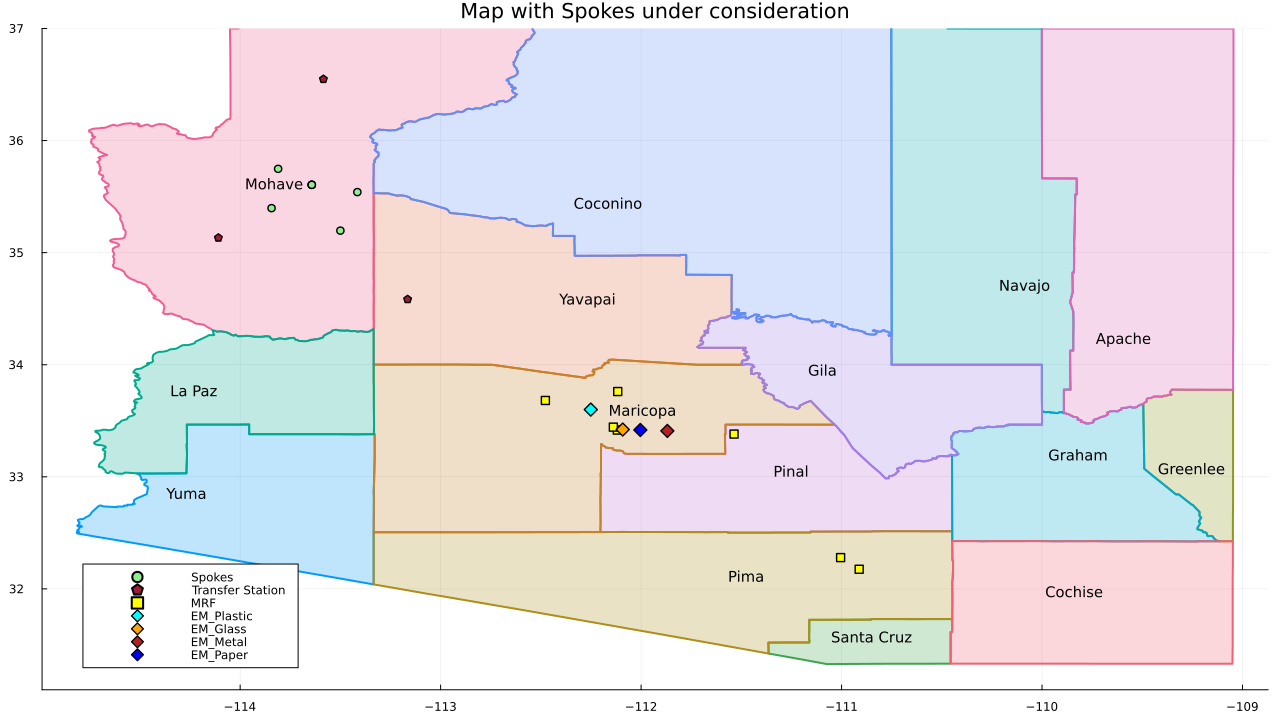

In [10]:
geo = JSON.parsefile("AZ.geojson")
features = geo["features"]
plot_shapes = []
counties = []

for feature in features
    coordinates = feature["geometry"]["coordinates"]
    county = feature["properties"]["name"]
    for ring in coordinates

        longitudes = [coord[1] for coord in ring]
        latitudes = [coord[2] for coord in ring]
        
        push!(plot_shapes, Shape(longitudes, latitudes))
        push!(counties, county)
    end
end

println("geography of ", length(plot_shapes), " counties.")
coordinates = geo["features"][2]["geometry"]["coordinates"][1]
longitudes = [coord[1] for coord in coordinates]
latitudes = [coord[2] for coord in coordinates]
data = DataFrame(plots_shapes=plot_shapes, value=rand(33.2:35, length(plot_shapes)), county=counties)
anim = Animation()

pp = plot()
qq = plot()

for (i, shape) in enumerate(data.plots_shapes)
    longitudes = shape.x
    latitudes = shape.y
    county_name = data.county[i]
    value = data.value[i]
    
    # regions
    plot!(pp, longitudes, latitudes, fillrange=0, fillalpha=0.25, size = (1280, 720), yrange = (33.2, 37.75), xrange=(-114.02, -111.85), label=false,
        linewidth=2, title = "scaled solution with a new hub establishment")
    plot!(qq, longitudes, latitudes, fillrange=0, fillalpha=0.25, yrange = (31.1, 37), size = (1280, 720), label=false, linewidth=2,
        title = "Map with Spokes under consideration")

    centroid_lon = mean(longitudes)
    centroid_lat = mean(latitudes)
    
    #  county name
    annotate!(qq, centroid_lon, centroid_lat, text(county_name, 10, :black))
end
scatter!(pp, S_dy, S_dx, markercolor = :lightgreen, label = "Spokes", markershape = :circle)
scatter!(pp, TS_dy, TS_dx, markercolor = :pink, label = "Transfer Station", markershape = :pentagon)
scatter!(pp, MRF_dy, MRF_dx, markercolor = :yellow, label = "MRF", markershape = :rect)
scatter!(pp, [EM_dy[1]], [EM_dx[1]], markercolor = :cyan, label = "EM_Plastic", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp, [EM_dy[2]], [EM_dx[2]], markercolor = :orange, label = "EM_Glass", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp, [EM_dy[3]], [EM_dx[3]], markercolor = :firebrick, label = "EM_Metal", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp, [EM_dy[4]], [EM_dx[4]], markercolor = palette([:blue, :green], 7), label = "EM_Paper", markershape = :diamond, markersize = 2 .* (3.25))
for i in 1:O
    for j in 1:O
        if value.(x[i, j]) > 0.5
            if i==j
                spoke = scatter!(pp, [S_dy[i], S_dy[j]], [S_dx[i], S_dx[j]]; label = false, color = "red", markersize = 2 .* (3.5))
                frame(anim, spoke)
            end
            alloc = plot!(pp, [S_dy[i], S_dy[j]], [S_dx[i], S_dx[j]]; color=:black, linewidth=0.9, label = false)
            frame(anim, alloc)
        end
    end
end
for i in 1:O
    for j in 1:M
        if value.(f3[i, j]) > 0.5
            HMalloc = plot!(pp, [S_dy[i], MRF_dy[j]], [S_dx[i], MRF_dx[j]]; label = false, color = "black")
            frame(anim, HMalloc)
        end
    end
end
for i in 1:O
    for j in 1:T
        if value.(f2[i, j]) > 0.5
            # scatter!([MRF_dx[j], MRF_dy[j]], [MRF_dx[j], MRF_dy[j]]; legend = false, color = "yellow", markershape = :rect)
            STalloc = plot!(pp, [S_dy[i], TS_dy[j]], [S_dx[i], TS_dx[j]]; label = false, color = "red")
            frame(anim, STalloc)
        end
    end
end
for i in 1:T
    for j in 1:M
        if value.(f4[i, j]) > 0.5
            # scatter!([MRF_dx[j], MRF_dy[j]], [MRF_dx[j], MRF_dy[j]]; legend = false, color = "yellow", markershape = :rect)
            TMalloc = plot!(pp, [TS_dy[i], MRF_dy[j]], [TS_dx[i], MRF_dx[j]]; label = false, color = "magenta")
            frame(anim, TMalloc)
        end
    end
end
for i in 1:M
    for j in 1:E
        if sum(value.(s1[1, i, j, :])) > 0.5
            MEalloc = plot!(pp, [MRF_dy[i], EM_dy[j]], [MRF_dx[i], EM_dx[j]]; linestyle = :dashdotdot,
                 linewidth=1, label = false, color = "black")
            frame(anim, MEalloc)
        end
    end
end
scatter_data = [
    (S_dy, S_dx, :lightgreen, "Spokes", :circle),
    (TS_dy, TS_dx, "#9C1D38", "Transfer Station", :pentagon),
    (TS_dy_1, TS_dx_1, "#9C1D38", "",:pentagon),
    (MRF_dy, MRF_dx, :yellow, "MRF", :rect),
]
for (dy, dx, color, label, shape) in scatter_data
    scatter!(qq, dy, dx, markercolor=color, label=label, markershape=shape)
end
scatter!(qq, [EM_dy[1]], [EM_dx[1]], markercolor = :cyan, label = "EM_Plastic", markersize = 2 .* (3.25), markershape = :diamond)
scatter!(qq, [EM_dy[2]], [EM_dx[2]], markercolor = :orange, label = "EM_Glass", markersize = 2 .* (3.25), markershape = :diamond)
scatter!(qq, [EM_dy[3]], [EM_dx[3]], markercolor = :firebrick, label = "EM_Metal", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(qq, [EM_dy[4]], [EM_dx[4]], markercolor = palette([:blue, :green], 7), label = "EM_Paper", markershape = :diamond, markersize = 2 .* (3.25))
plot(qq)
# gif(anim, fps=5)

**Mohave County (within State Business)**
* Existing Configuration (flow through transfer station)
* Establishing a new hub in Mohave 

**With Existing Transfer station within Mohave County**

In [6]:
S_dx_1 = zip[462:468, 2]
S_dy_1 = zip[462:468, 3]
TS_dx_1 = Transfer_station[85:86, 3]
TS_dy_1 = Transfer_station[85:86, 4]
EM_dx_1 = facility[23:26,2]
EM_dy_1 = facility[23:26,3]
MRF_dx_1 = facility[1:7, 2]
MRF_dy_1 = facility[1:7, 3]
# dS = [haversine(S_dx[i], S_dy[i], S_dx[j], S_dy[j]) for i in 1:length(S_dx), j in 1:length(S_dx)]
dS_TS = [haversine(S_dx[i], S_dy[i], TS_dx_1[j], TS_dy_1[j]) for i in 1:length(S_dx), j in 1:length(TS_dx_1)]
# dS_MRF = [haversine(S_dx[i], S_dy[i], MRF_dx[j], MRF_dy[j]) for i in 1:length(S_dx), j in 1:length(MRF_dx)]
dTS_MRF = [haversine(TS_dx_1[i], TS_dy_1[i], MRF_dx[j], MRF_dy[j]) for i in 1:length(TS_dx_1), j in 1:length(MRF_dx)]
dMRF_EM = [haversine(MRF_dx[i], MRF_dy[i], EM_dx[j], EM_dy[j]) for i in 1:length(MRF_dx), j in 1:length(EM_dx)]
input_dataframe = (Spoke_lat = S_dx_1, Spoke_long = S_dy_1, TS_lat = TS_dx_1, TS_long = TS_dy_1, 
    MRF_lat = MRF_dx_1, MRF_long = MRF_dy_1, EM_lat = EM_dx_1, EM_long = EM_dy_1)
pretty_table(input_dataframe, header = ["Spoke_lat", "Spoke_long", "TS_lat", "TS_long", "MRF_lat", "MRF_long", "EM_lat", "EM_long"])
O = length(S_dx)
T = length(TS_dx_1)
M = length(MRF_dx)
E = length(EM_dx)
Ph = 8
N = 50
Indicator = DataFrame(CSV.File("Indicator.csv"))
Comp = [0.33, 0.25, 0.1, 0.1, 0.05, 0.05, .02, 0.1] 
b= rand(30:50, O)
diagonal_values = ones(O) * 0
Rm = 200* rand(M, Ph)
# Generate random values for all elements
all_values = 2 * dS

# Create the final matrix
c = 4 * rand(1:3, O,E)
cap_h = rand(525:725, O) 
cap_z1 = rand(202:259, M)
cz1 = 500 * ones(M)
c1 = all_values
for i in 1:O
    c1[i, i] = diagonal_values[i]
end
c2 = 2 * dS_TS
c3 = 2 * dS_MRF
c4 = 2 * dTS_MRF
c5 = 2 * dMRF_EM
c_Lf = 60
c_buy = 20*rand(3:8, M,Ph)
c_op = 5*rand(4:10, M,Ph)
Q = 10*rand(Uniform(0.9,1.0),Ph)
H = 2*rand(4:8, Ph)
D = 0.3
big_M = 10000
ef= rand(0.8:0.01:0.95, N, M, Ph)
ef_max = zeros(1:Ph)
for p in 1:Ph
    ef_max[p] = (maximum(ef[:,:,p]))
end

cost_hub = rand(50205:52255, O)
Random.seed!(456)
r2 = rand(0.6:0.01:0.8, N, M)
r1 = rand(0.75:0.01:0.93, N, M) 
r1_max = maximum(r1)
r2_max = maximum(r2)
# r2 = rand(0.2:0.1:0.7, N, M)
I = Indicator[1:4, :]

model_1 = Model(HiGHS.Optimizer)
# set_optimizer_attribute(model, "OutputFlag", 0)
set_time_limit_sec(model_1, 1800.0)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Here and Now)
@variable(model_1, x2_1[1:O, 1:T] >=0, Bin)
@variable(model_1, f2_1[1:O, 1:T] >=0)
@variable(model_1, f4_1[1:T, 1:M] >=0)
# @variable(model, z1[1:M], Bin)
# @variable(model, y[1:O], Bin)

@constraint(model_1, assgn[i in 1:O], sum(x2_1[i, j] for j in 1:T) == 1)
@constraint(model_1, flow_h_t_m[j in 1:T], sum(f2_1[i, j] for i in 1:O) == 
        sum(x2_1[i, j] * b[i] for i in 1:O))
@constraint(model_1, flow_t_a[t in 1:T], sum(f2_1[i, t] for i in 1:O) == sum(f4_1[t, m] for m in 1:M))

# Second stage variable (See and follow)
@variable(model_1, 0 <= w1_1[1:N, 1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model_1, 0 <= s1_1[1:N, 1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

#Recourse Constraints(for hub)
@constraint(model_1, d1[n in 1:N, m in 1:M], w1_1[n, m, 1] == sum(f4_1[j,m] * r2[n, m] for j in 1:T))
# @constraint(model, d2[n in 1:N, m in 1:M], -w1[n, m, 1] >= -sum(f3[j,m] for j in 1:O)*r1[n, m] - sum(f4[j,m] for j in 1:T)*r2[n, m])
@constraint(model_1, d2[n in 1:N, m in 1:M], w1_1[n, m, 2] == sum(f4_1[i, m] for i in 1:T) -sum(s1_1[n, m, e, 1] for e in 1:E))
@constraint(model_1, d3[n in 1:N, m in 1:M, p in 2:Ph], w1_1[n, m, p+1] == w1_1[n,m,p] -sum(s1_1[n, m, e, p] for e in 1:E))

@constraint(model_1, d4[n in 1:N, m in 1:M, p in 1:Ph], sum(s1_1[n, m, e, p] for e in 1:E)  <= w1_1[n, m, 1]*Comp[p]*ef[n, m, p])
@constraint(model_1, d5[n in 1:N, e in 1:E, p in 1:Ph], sum(s1_1[n, m, e, p] for m in 1:M) >= D * Comp[p] * I[e, p] * sum(b[i] for i in 1:O) * (1/E))

MRF_cost = c_Lf * (sum(w1_1[n,m, Ph+1] for n in 1:N for m in 1:M))
spoke_transfer = sum(c2[i, j] * f2_1[i, j] for i in 1:O for j in 1:T)
transfer_mrf = sum(c4[i, j] * f4_1[i, j] for i in 1:T for j in 1:M)
 
first_stage =  spoke_transfer + transfer_mrf

# source_hub_cost = sum(c1[i, j] * x[j, j] for i in 1:O for j in 1:O if i!=j)

# revenue = sum(Rm[m, p] * s1[n, m, j, p] for n in 1:N for m in 1:M for j in 1:E for p in 1:Ph)
@objective(model_1, Min, first_stage + 1/(N) * (MRF_cost))
# unset_binary.(x)
optimize!(model_1)
gurobi_runtime = solve_time(model_1)
println("runtime: ", gurobi_runtime)
objective_value(model_1)

┌───────────┬────────────┬─────────┬──────────┬─────────┬──────────┬─────────┬──────────┐
│ Spoke_lat │ Spoke_long │  TS_lat │  TS_long │ MRF_lat │ MRF_long │  EM_lat │  EM_long │
├───────────┼────────────┼─────────┼──────────┼─────────┼──────────┼─────────┼──────────┤
│   35.5404 │   -113.415 │ 35.1323 │ -114.109 │ 33.7608 │ -112.116 │ 33.5999 │ -112.251 │
│   35.6053 │   -113.643 │ 36.5481 │ -113.585 │  33.417 │ -112.119 │ 33.4219 │ -112.092 │
│   35.6053 │   -113.643 │  #undef │   #undef │ 33.4432 │ -112.138 │ 33.4096 │ -111.869 │
│   35.6053 │   -113.643 │  #undef │   #undef │ 33.6812 │ -112.477 │ 33.4179 │ -112.004 │
│   35.1966 │     -113.5 │  #undef │   #undef │ 33.3813 │ -111.536 │  #undef │   #undef │
│   35.7478 │   -113.811 │  #undef │   #undef │ 32.2792 │ -111.005 │  #undef │   #undef │
│   35.3972 │   -113.843 │  #undef │   #undef │ 32.1751 │ -110.912 │  #undef │   #undef │
└───────────┴────────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┘
Running Hi

98308.29650665776

**Mohave County New hub Establishment**

In [7]:
# Data

T = length(TS_dx)

ratio = zeros(O)
for i in 1:O
    ratio[i] = (cost_hub[i] ./ cap_h[i])
end
sortperm(ratio)
function add_until_threshold(cap_h)
    current_sum = 0
    selected_elements = []

    for i in sort(cap_h, rev = true) 
        push!(selected_elements, i)  
        current_sum += i 
        if current_sum >= sum(b)  # Check if the threshold is reached
            break  
        end
    end

    return selected_elements, current_sum  # Return the selected elements and the final sum
end
selected_elements, total_sum = add_until_threshold(cap_h)
num = length(selected_elements)
ub = zeros(O)
for j in 1:O
    model = Model(HiGHS.Optimizer)
    set_silent(model)

    @variable(model, 0 <= UB[1:O, j] <= 1, Bin)
    
    # Adjusted constraint to avoid the warning
    @constraint(model, sum(UB[i, j] * b[i] for i in 1:O if i != j) <= (cap_h[j] - b[j]))
    
    # Objective definition
    @objective(model, Max, sum(sum(UB[i, j] for i in 1:O if i != j)))
    
    optimize!(model)
    ub[j] = sum(value(UB[i, j]) for i in 1:O)
end
model = Model(HiGHS.Optimizer)
# set_optimizer_attribute(model, "OutputFlag", 0)
set_time_limit_sec(model, 1800.0)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Hqere and Now)
@variable(model, 0 <= x[1:O, 1:O] <=1, Bin)
@variable(model, f2[1:O, 1:T] >=0)
@variable(model, f3[1:O, 1:M] >=0)
@variable(model, f4[1:T, 1:M] >=0)
# @variable(model, z1[1:M], Bin)
# @variable(model, y[1:O], Bin)
@variable(model, ft[1:T] >=0)
@variable(model, fh[1:O] >=0)

@constraint(model, assgn[i in 1:O], sum(x[i, j] for j in 1:O) == 1)
@constraint(model, assgn2[i in 1:O, j in 1:O], x[i, j] <= x[j,j])
@constraint(model, cap[j in 1:O], sum(x[i, j] * b[i] for i in 1:O) <= cap_h[j]* x[j, j])
@constraint(model, flow_h_t_m[j in 1:O], sum(f2[j, t] for t in 1:T) + sum(f3[j, m] for m in 1:M) == 
        sum(x[i, j] * b[i] for i in 1:O))
@constraint(model, flow_t_a[t in 1:T], sum(f2[i, t] for i in 1:O) == sum(f4[t, m] for m in 1:M))

# List of Valid Inequalities

@constraint(model, hub_VI, sum(x[j, j] for j in 1:O) >= ceil(sum(b[i] for i in 1:O)/maximum(cap_h)))

@constraint(model, hub_VIalt, sum(x[j, j] for j in 1:O) >= num)

@constraint(model, arc_ub[j in 1:O], sum(x[i, j] for i in 1:O if i!=j) <= (ub[j]) * x[j, j])



# Second stage variable (See and follow)
@variable(model, 0 <= w1[1:N, 1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= s1[1:N, 1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

#Recourse Constraints(for hub)
@constraint(model, d1[n in 1:N, m in 1:M], w1[n, m, 1] == sum(f3[j,m] for j in 1:O) * r1[n, m]  + sum(f4[j,m] * r2[n, m] for j in 1:T))
# @constraint(model, d2[n in 1:N, m in 1:M], -w1[n, m, 1] >= -sum(f3[j,m] for j in 1:O)*r1[n, m] - sum(f4[j,m] for j in 1:T)*r2[n, m])
@constraint(model, d2[n in 1:N, m in 1:M], w1[n, m, 2] == sum(f3[i, m] for i in 1:O) + sum(f4[i, m] for i in 1:T) -sum(s1[n, m, e, 1] for e in 1:E))
@constraint(model, d3[n in 1:N, m in 1:M, p in 2:Ph], w1[n, m, p+1] == w1[n,m,p] -sum(s1[n, m, e, p] for e in 1:E))
# @constraint(model, d3[n in 1:N, m in 1:M, j in 1:E, p in 1:Ph], s1[n, m, j, p] <= big_M * y1[n, m, j])
# @constraint(model, d5[n in 1:N, m in 1:M, p in 1:Ph], sum(y1[n, m, j, p] for j in 1:E) <= 1)
@constraint(model, d4[n in 1:N, m in 1:M, p in 1:Ph], sum(s1[n, m, e, p] for e in 1:E)  <= w1[n, m, 1]*Comp[p]*ef[n, m, p])
# @constraint(model, d5[n in 1:N, e in 1:E-1, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M)- sum(s1[n, m, e+1, p] for m in 1:M)  <=0)
@constraint(model, d5[n in 1:N, e in 1:E, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M) >= D * Comp[p] * I[e, p] * sum(b[i] for i in 1:O) * (1/E))

MRF_cost = c_Lf * (sum(w1[n,m, Ph+1] for n in 1:N for m in 1:M))
spoke_hub = sum(c1[i, j] * x[i, j] * b[i] for i in 1:O for j in 1:O)
hub_transfer = sum(c2[i, j] * 0.65 * f2[i, j] for i in 1:O for j in 1:T)
hub_mrf = sum(c3[i, j] * f3[i, j] for i in 1:O for j in 1:M)
transfer_mrf = sum(c4[i, j] * f4[i, j] for i in 1:T for j in 1:M)
Hub_cap_cost = sum(cost_hub[j] * x[j, j] for j in 1:O) 

first_stage =  spoke_hub +  hub_transfer + hub_mrf + transfer_mrf + Hub_cap_cost

# source_hub_cost = sum(c1[i, j] * x[j, j] for i in 1:O for j in 1:O if i!=j)

# revenue = sum(Rm[m, p] * s1[n, m, j, p] for n in 1:N for m in 1:M for j in 1:E for p in 1:Ph)
@objective(model, Min, first_stage + 1/(N) * (MRF_cost))
# unset_binary.(x)
optimize!(model)
gurobi_runtime = solve_time(model)
println("runtime: ", gurobi_runtime)
objective_value(model)

┌ Warning: Axis contains one element: 1. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[1]` instead of `1`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 2. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[2]` instead of `2`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 3. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[3]` instead of `3`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 4. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[4]` instead of `4`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\

Running HiGHS 1.8.1 (git hash: 4a7f24ac6): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-02, 7e+02]
  Cost   [6e-03, 5e+04]
  Bound  [1e+00, 1e+00]
  RHS    [4e-01, 7e+00]
Presolving model
6423 rows, 14462 cols, 39564 nonzeros  0s
4388 rows, 12427 cols, 35494 nonzeros  0s
3972 rows, 6412 cols, 23457 nonzeros  0s
3972 rows, 3612 cols, 17857 nonzeros  0s

Solving MIP model with:
   3972 rows
   3612 cols (49 binary, 0 integer, 0 implied int., 3563 continuous)
   17857 nonzeros
MIP-Timing:        0.27 - starting analytic centre calculation

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic; L => Sub-MIP;
     P => Empty MIP; R => Randomized rounding; S => Solve LP; T => Evaluate node; U => Unbounded;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. InQueue 

139136.6342532896

In [15]:
objective_value(model)-value.(Hub_cap_cost)

83595.37724998035

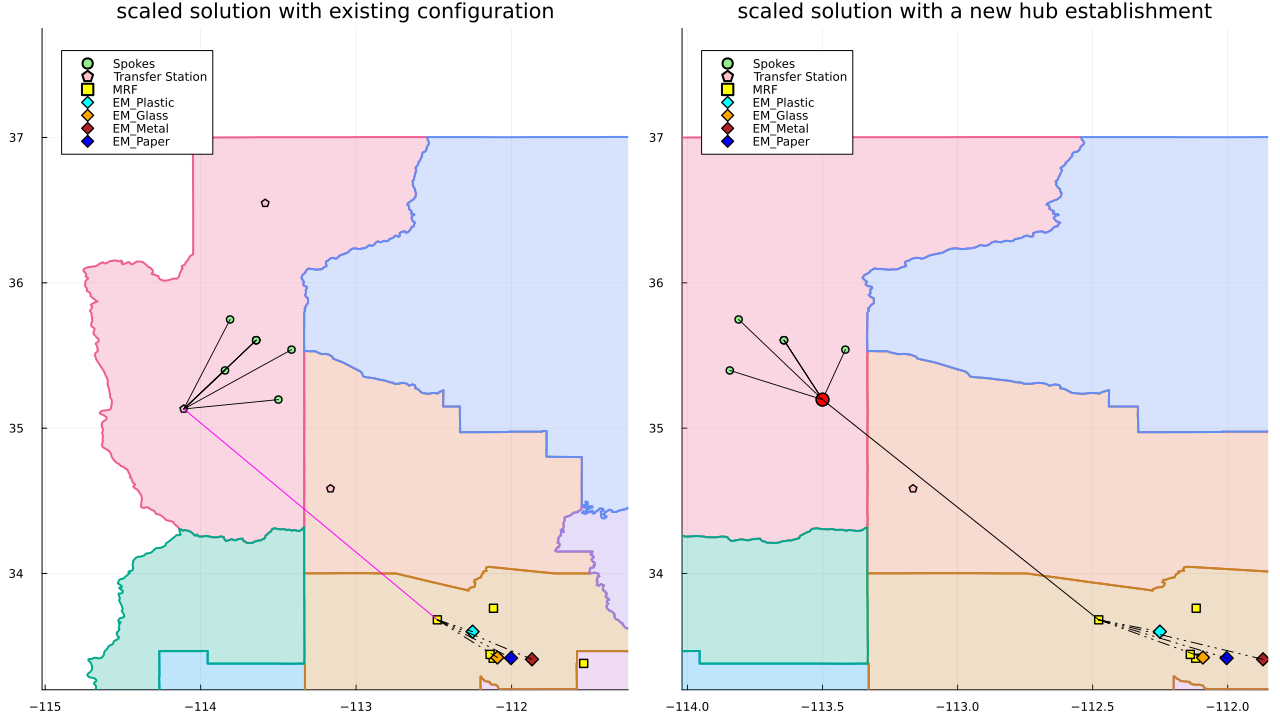

In [11]:
geo = JSON.parsefile("AZ.geojson")
features = geo["features"]
plot_shapes = []
counties = []

for feature in features
    coordinates = feature["geometry"]["coordinates"]
    county = feature["properties"]["name"]
    for ring in coordinates

        longitudes = [coord[1] for coord in ring]
        latitudes = [coord[2] for coord in ring]
        
        push!(plot_shapes, Shape(longitudes, latitudes))
        push!(counties, county)
    end
end

coordinates = geo["features"][2]["geometry"]["coordinates"][1]
longitudes = [coord[1] for coord in coordinates]
latitudes = [coord[2] for coord in coordinates]
data = DataFrame(plots_shapes=plot_shapes, value=rand(33.2:35, length(plot_shapes)), county=counties)
anim = Animation()

pp_1 = plot()
qq_1 = plot()

for (i, shape) in enumerate(data.plots_shapes)
    longitudes = shape.x
    latitudes = shape.y
    county_name = data.county[i]
    value = data.value[i]
    
    # regions
    plot!(pp_1, longitudes, latitudes, fillrange=0, fillalpha=0.25, size = (1280, 720), yrange = (33.2, 37.75), xrange=(-115.02, -111.25), label=false,
        linewidth=2, title = "scaled solution with existing configuration")
    plot!(qq_1, longitudes, latitudes, fillrange=0, fillalpha=0.25, yrange = (31.1, 37), size = (1280, 720), label=false, linewidth=2,
        title = "Location of the facility")

    centroid_lon = mean(longitudes)
    centroid_lat = mean(latitudes)
    
    #  county name
    annotate!(qq_1, centroid_lon, centroid_lat, text(county_name, 10, :black))
end
scatter!(pp_1, S_dy_1, S_dx_1, markercolor = :lightgreen, label = "Spokes", markershape = :circle)
scatter!(pp_1, TS_dy, TS_dx, markercolor = :pink, label = "", markershape = :pentagon)
scatter!(pp_1, TS_dy_1, TS_dx_1, markercolor = :pink, label = "Transfer Station", markershape = :pentagon)
scatter!(pp_1, MRF_dy_1, MRF_dx_1, markercolor = :yellow, label = "MRF", markershape = :rect)
scatter!(pp_1, [EM_dy_1[1]], [EM_dx_1[1]], markercolor = :cyan, label = "EM_Plastic", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp_1, [EM_dy_1[2]], [EM_dx_1[2]], markercolor = :orange, label = "EM_Glass", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp_1, [EM_dy_1[3]], [EM_dx_1[3]], markercolor = :firebrick, label = "EM_Metal", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp_1, [EM_dy_1[4]], [EM_dx_1[4]], markercolor = palette([:blue, :green], 7), label = "EM_Paper", markershape = :diamond, markersize = 2 .* (3.25))
for i in 1:O
    for j in 1:T
        if value.(x2_1[i, j]) > 0.5
            alloc = plot!(pp_1, [S_dy_1[i], TS_dy_1[j]], [S_dx_1[i], TS_dx_1[j]]; color=:black, linewidth=0.9, label = false)
            frame(anim, alloc)
        end
    end
end

for i in 1:T
    for j in 1:M
        if value.(f4_1[i, j]) > 0.5
            # scatter!([MRF_dx[j], MRF_dy[j]], [MRF_dx[j], MRF_dy[j]]; legend = false, color = "yellow", markershape = :rect)
            TMalloc = plot!(pp_1, [TS_dy_1[i], MRF_dy_1[j]], [TS_dx_1[i], MRF_dx_1[j]]; label = false, color = "magenta")
            frame(anim, TMalloc)
        end
    end
end
for i in 1:M
    for j in 1:E
        if sum(value.(s1_1[1, i, j, :])) > 0.5
            MEalloc = plot!(pp_1, [MRF_dy_1[i], EM_dy_1[j]], [MRF_dx_1[i], EM_dx_1[j]]; linestyle = :dashdotdot,
                 linewidth=1, label = false, color = "black")
            frame(anim, MEalloc)
        end
    end
end

plot(pp_1, pp)
# gif(anim, fps=5)

In [9]:
n_values = Int[]
# m_values = Int[]
# e_values = Int[]
p_values = Int[]
value_values = Float64[] 
value_values_1 = Float64[] 
lf_value = Float64[]
lf_value_1 = Float64[]
Diversion = Float64[]
Diversion_1 = Float64[]

for n in 1:N
    #for m in 1:M
        #for e in 1:E
            for p in 1:Ph
              if sum(value.(s1[n, :, :, p])) > 0
                push!(n_values, n)
                #push!(m_values, m)
                #push!(e_values, e)
                push!(p_values, p)
                push!(value_values, sum(value.(s1[n, :, :, p])))
                push!(value_values_1, sum(value.(s1_1[n, :, :, p])))
                push!(lf_value, sum(value.(w1[n, :, Ph+1])))
                push!(lf_value_1, sum(value.(w1_1[n, :, Ph+1])))
                push!(Diversion, sum(value.(s1[n, :, :, :]))/ sum(b))
                push!(Diversion_1, sum(value.(s1_1[n, :, :, :]))/ sum(b))
              end
            end
        #end
    #end
end
dtfr_stack = DataFrame(n=n_values, p = p_values, recycling_1 = Diversion_1, recycling = Diversion)
dtfr = unstack(dtfr_stack, :p, :n)
# Print output table
df_stack = DataFrame(n=n_values,  p=p_values, Value=value_values, Lf = lf_value, recycling = Diversion)
df = unstack(df_stack, :p,  :Value)
df = select(df, Not([:Lf, :recycling]), :Lf, :recycling)
rename!(df, ["Scenario", "Cardboard", "Other Paper", "Clean Glass", "Colored Glass", "PET", "Other Plastic", "Aluminum", "Other Met", 
        "Landfill Qt", "Recyling Rate"])
pretty_table(df, header = ["Scenario", "Cardboard", "Other Paper", "Clean Glass", "Colored Glass", "PET", "Other Plastic", "Aluminum", "Other Metals", 
        "Lf Quantity", "Recyling Rate"])

┌──────────┬───────────┬─────────────┬─────────────┬───────────────┬─────────┬───────────────┬──────────┬──────────────┬─────────────┬───────────────┐
│ Scenario │ Cardboard │ Other Paper │ Clean Glass │ Colored Glass │     PET │ Other Plastic │ Aluminum │ Other Metals │ Lf Quantity │ Recyling Rate │
├──────────┼───────────┼─────────────┼─────────────┼───────────────┼─────────┼───────────────┼──────────┼──────────────┼─────────────┼───────────────┤
│        1 │   65.7829 │     54.0898 │     20.9066 │       20.6635 │ 11.5473 │       10.0886 │  4.47304 │      19.9342 │     78.5142 │      0.725475 │
│        2 │    61.045 │     51.7517 │     19.5996 │       19.3794 │ 10.2402 │        8.8088 │  4.18418 │      18.7187 │     92.2725 │      0.677369 │
│        3 │   69.6524 │      52.767 │     21.6216 │        20.592 │  11.583 │       12.0978 │  4.22136 │      21.1068 │      72.358 │         0.747 │
│        4 │   76.4384 │     54.0897 │     23.4177 │        22.145 │ 10.8179 │       10.5634 │

In [12]:
pretty_table(dtfr)

┌─────────────┬───────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ recycling_1 │ recycling │      1 │      2 │      3 │      4 │      5 │      6 │      7 │      8 │
│     Float64 │   Float64 │ Int64? │ Int64? │ Int64? │ Int64? │ Int64? │ Int64? │ Int64? │ Int64? │
├─────────────┼───────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│     0.66573 │  0.725475 │      1 │      1 │      1 │      1 │      1 │      1 │      1 │      1 │
│    0.677369 │  0.677369 │      2 │      2 │      2 │      2 │      2 │      2 │      2 │      2 │
│      0.5312 │     0.747 │      3 │      3 │      3 │      3 │      3 │      3 │      3 │      3 │
│      0.6825 │   0.77875 │      4 │      4 │      4 │      4 │      4 │      4 │      4 │      4 │
│      0.6351 │    0.6873 │      5 │      5 │      5 │      5 │      5 │      5 │      5 │      5 │
│    0.657195 │   0.64866 │      6 │      6 │      6 │      6 │      6 │      6 │      6 │      6 │
